# **Data Visualization**

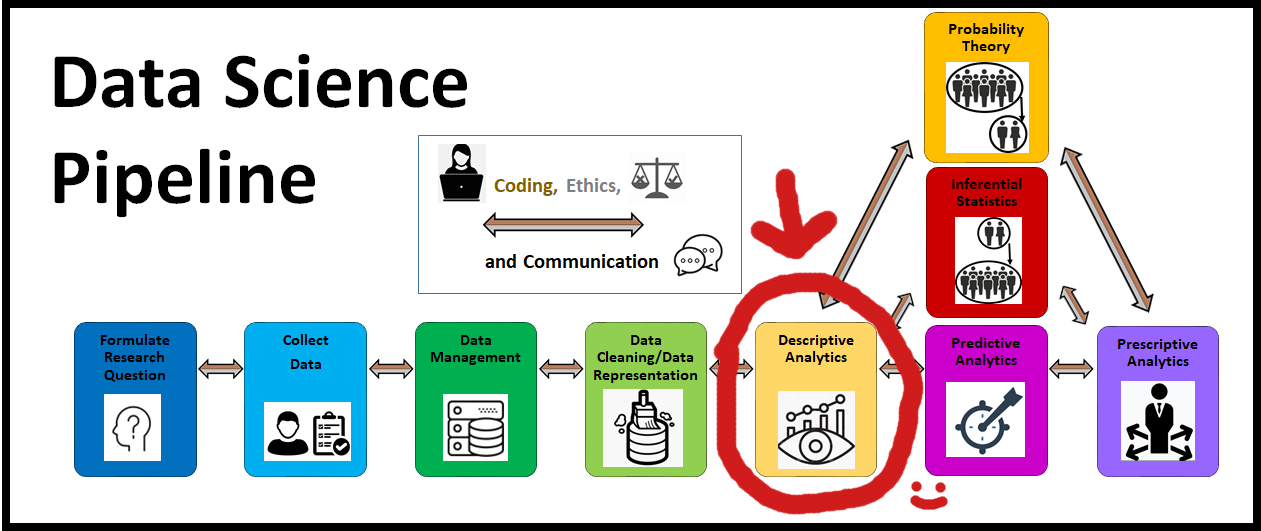

Welcome to the data visualization workshop! After your data is all cleaned up, the next step is to start with some **exploratory data analysis** (EDA). This involves looking for trends and relationships in the data that might help with your goal, which in our case is building a model. While you could try and spot patterns by looking at hundreds of thousands of numbers in Excel, our preferred method is using data visualization. In this workshop, we will use `matplotlib` and `seaborn`, two of the most popular data visualization libraries in Python, to construct scatterplots, heatmaps, and other graphs that you can use with your own data.

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.colors import CenteredNorm

The first dataset we will work is a slightly old dataset with information about world billionaires. Each row contains information on the billionaire's race, company, etc.

In [49]:
# import dataset

df = pd.read_csv("billionaires.csv") 
df = df.loc[df.groupby("name")["year"].idxmax()].sort_values("rank") # get only the most recent record for each billionaire

In [18]:
df.head()

,name,rank,year,company.founded,company.name,company.relationship,company.sector,company.type,demographics.age,demographics.gender,...,location.gdp,location.region,wealth.type,wealth.worth in billions,wealth.how.category,wealth.how.from emerging,wealth.how.industry,wealth.how.inherited,wealth.how.was founder,wealth.how.was political
2,Bill Gates,1,2014,1975,Microsoft,founder,Software,new,58,male,...,0.000000e+00,North America,founder non-finance,76.0,New Sectors,True,Technology-Computer,not inherited,True,True
5,Carlos Slim Helu,2,2014,1990,Telmex,founder,Communications,privatization,74,male,...,0.000000e+00,Latin America,privatized and resources,72.0,Non-Traded Sectors,True,Media,not inherited,True,True
8,Amancio Ortega,3,2014,1975,Zara,founder,Fashion,new,77,male,...,0.000000e+00,Europe,founder non-finance,64.0,Non-Traded Sectors,True,"Retail, Restaurant",not inherited,True,True
6,Oeri Hoffman and Sacher,3,1996,1896,F. Hoffmann-La Roche,NaN,pharmaceuticals,new,0,NaN,...,3.300000e+11,Europe,inherited,13.1,New Sectors,True,Technology-Medical,3rd generation,True,True
11,Warren Buffett,4,2014,1839,Berkshire Hathaway,founder,Finance,aquired,83,male,...,0.000000e+00,North America,founder non-finance,58.2,Traded Sectors,True,Consumer,not inherited,True,True


In [19]:
df.columns

Index(['name', 'rank', 'year', 'company.founded', 'company.name',
       'company.relationship', 'company.sector', 'company.type',
       'demographics.age', 'demographics.gender', 'location.citizenship',
       'location.country code', 'location.gdp', 'location.region',
       'wealth.type', 'wealth.worth in billions', 'wealth.how.category',
       'wealth.how.from emerging', 'wealth.how.industry',
       'wealth.how.inherited', 'wealth.how.was founder',
       'wealth.how.was political'],
      dtype='str')

Let's start with a basic scatterplot, graphing `Year Acquired` against `Square Footage` to look for a relationship. Do more recently-acquired buildings tend to be bigger?

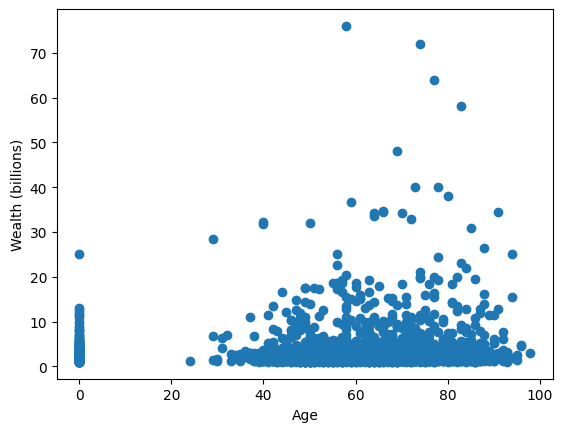

In [ ]:
plt.scatter(x=df['demographics.age'], y=df['wealth.worth in billions'])
plt.xlabel("Age")
plt.ylabel("Net Worth (billions)")
plt.show()

Most of our data is clustered around low datapoints, which makes it hard to identify trends. There's also a bunch of billionaire babies! In this case, we can try adjusting the scale of the graph. There are a couple ways to do this, the first is by rescaling our `y` variable. Let's try a square-root scale, which is good for squashing down small values and spreading out low clusters.

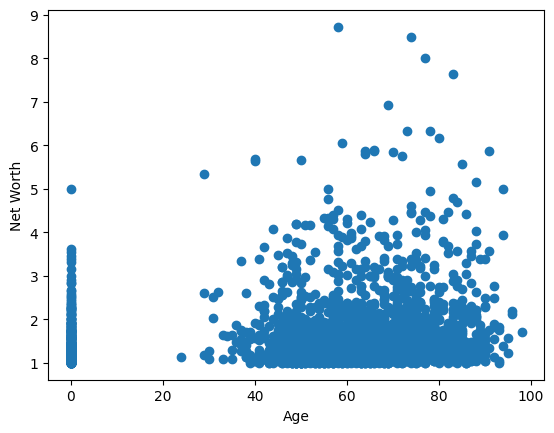

In [23]:
plt.scatter(x=df['demographics.age'], y=np.sqrt(df['wealth.worth in billions']))
plt.xlabel("Age")
plt.ylabel("Net Worth")
plt.show()

Looks better, but we still have quite the cluster. Another scale we could use that spreads the data even further is a log scale. Instead of manually transforming our `y` variable, we can just use `plt.yscale('log')`.

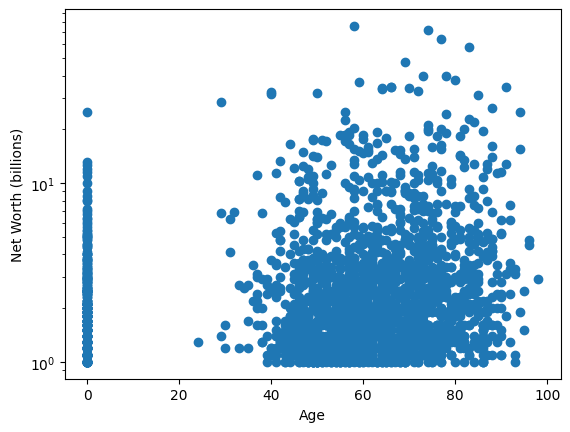

In [51]:
plt.scatter(x=df['demographics.age'], y=df['wealth.worth in billions'])
plt.xlabel("Age")
plt.ylabel("Net Worth (billions)")
plt.yscale('log') 
plt.show()

The vertical clustering is generally gone! This allows us to confirm that there doesn't seem to be a trend in the average square footage increasing or decreasing over time.

Next, let's look at the sectors with the most billionaires.

In [26]:
top_sectors = df['company.sector'].value_counts()[:5]
top_sectors

company.sector
real estate     145
retail           93
construction     82
media            79
banking          72
Name: count, dtype: int64

For this, we can use a bar plot.

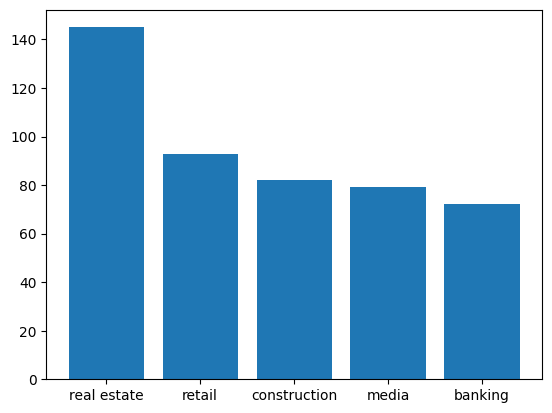

In [58]:
# matplotlib version

plt.bar(top_sectors.index, top_sectors.values)
plt.show()

Let's make this prettier... we should add labels, a [color map](https://matplotlib.org/stable/users/explain/colors/colormaps.html), and we can even change the font.

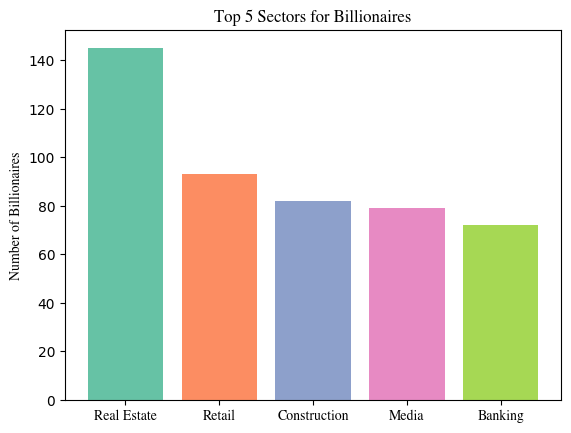

In [ ]:
# make it pretty!

plt.bar(top_sectors.index, top_sectors.values, color=colormaps['Set2'].colors)
plt.ylabel("Number of Billionaires", fontname="Times")
plt.title("Top 5 Sectors for Billionaires", fontname="Times")
plt.xticks(range(5), ["Real Estate", "Retail", "Construction", "Media", "Banking"], fontname="Times")
plt.show()

What if we want to view something more than just counts, like the distribution of net worth in each sector?

In [30]:
df_top_sectors = df[df['company.sector'].isin(top_sectors.index)] # only select observations from these 5 sectors

In [33]:
top_sectors_worth = df_top_sectors.groupby("company.sector").agg('max', numeric_only=True)['wealth.worth in billions'].sort_values() # find the building with the most floors in each
top_sectors_worth

company.sector
construction    12.8
banking         16.0
media           22.6
real estate     31.0
retail          34.7
Name: wealth.worth in billions, dtype: float64

We can use a violin plot! Violin plots are similar to box plots but with more information; rather than just the quantiles, violin plots display the distributions for each city.

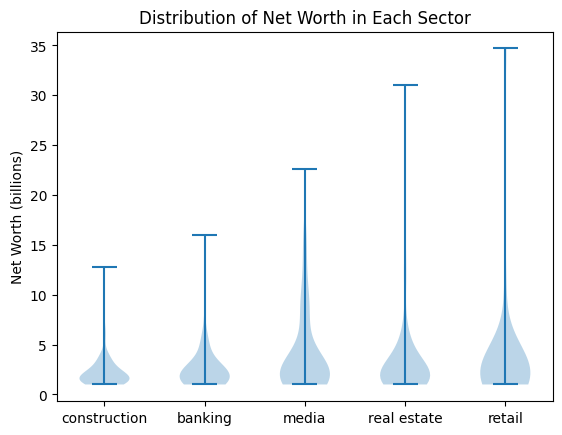

In [34]:
plt.violinplot(dataset= 
    [df[df['company.sector'] == "construction"]['wealth.worth in billions'].values,
    df[df['company.sector'] == "banking"]['wealth.worth in billions'].values,
    df[df['company.sector'] == "media"]['wealth.worth in billions'].values,
    df[df['company.sector'] == "real estate"]['wealth.worth in billions'].values,
    df[df['company.sector'] == "retail"]['wealth.worth in billions'].values]
)

plt.xticks(ticks=list(range(1, 6)), labels=top_sectors_worth.index)
plt.ylabel("Net Worth (billions)")
plt.title("Distribution of Net Worth in Each Sector")
plt.show()

# this is easier in seaborn... 

The next visualization is one of the most important and reusable graphs you'll ever have; a **correlation heatmap**. When we have a bunch of variables, it's common for us to want to know how they are correlated with one another. This is a vital question in both modeling and descriptive analytics; those of you familiar with linear regression know this. So, let's generate a correlation matrix! Each entry in this matrix represents the correlation between the two variables intersecting.

In [ ]:
corr = df.corr(numeric_only=True)
corr = corr.dropna(axis=0, how="all").dropna(axis=1, how="all") # get rid of all-NA rows and columns
corr

,rank,year,company.founded,demographics.age,location.gdp,wealth.worth in billions
rank,1.000000,0.460939,0.081009,0.168222,-0.298707,-0.470212
year,0.460939,1.000000,0.229083,0.556719,-0.612726,0.110720
company.founded,0.081009,0.229083,1.000000,0.169116,-0.064598,0.039329
demographics.age,0.168222,0.556719,0.169116,1.000000,-0.198621,0.123527
location.gdp,-0.298707,-0.612726,-0.064598,-0.198621,1.000000,-0.072578
wealth.worth in billions,-0.470212,0.110720,0.039329,0.123527,-0.072578,1.000000


The table is nice and all, but when we have many variables, it's difficult to look at that mess of numbers and get a quick measure of which variables are strongly correlated. Instead, we use a heatmap.

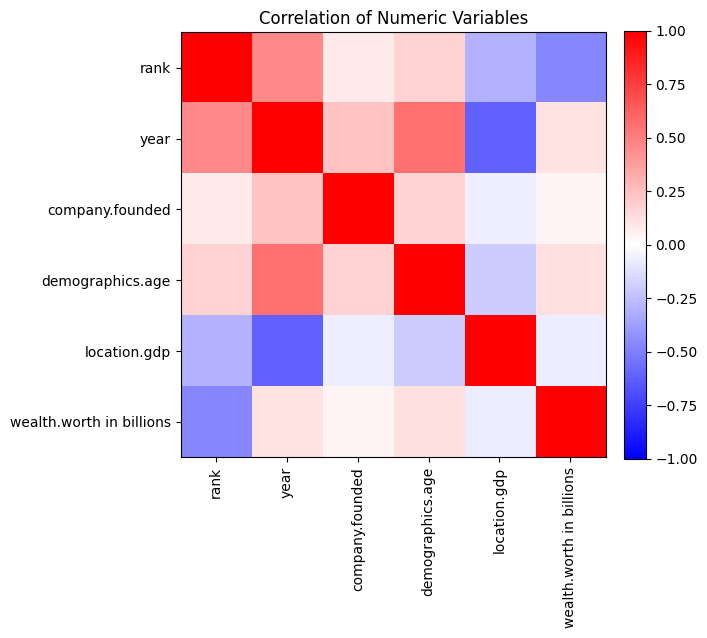

In [48]:
# matplotlib version

plt.figure(figsize=(6, 6))
plt.imshow(corr, cmap='bwr', norm=CenteredNorm()) # centers colorbar around 0 
plt.xticks(range(6), labels=corr.columns.values, rotation=90)
plt.yticks(range(6), labels=corr.columns.values)
plt.colorbar(fraction=0.046, pad=0.04) # scale colorbar to be same size as plot 
plt.title("Correlation of Numeric Variables")
plt.show()

Now it's much easier to spot highly correlated variables. The <span style="color:pink;">red</span>-<span style="color:lightblue;">blue</span> color scheme is extremely common for heatmaps; red naturally lends itself to "warmer" or "higher" values while blue does the opposite.

Here we have linked the full documentation for [Matplotlib](https://matplotlib.org/stable/index.html), [Seaborn](https://seaborn.pydata.org/) and niche [Altair](https://altair-viz.github.io/). Making sure your visualizations are easy to grasp and aesthetically pleasing is more important than you might think (for example, you might be familiar with [this](https://waf.cs.illinois.edu/discovery/every_gen_ed_at_uiuc_by_gpa/) beautiful one). So do some research and make them pretty!

## Try it on your own!
Using one of the datasets we provided (or your own!) make a beautiful visualization...

In [ ]:
# code here

